# 7. 전이학습 - Dogs vs Cats 실전 분류

## 학습 목표
1. Kaggle 데이터셋을 PyTorch ImageFolder 형식으로 준비할 수 있다
2. 기본 CNN, 이미지 증강 CNN, 전이학습 모델의 성능을 비교할 수 있다
3. 이미지 증강이 학습에 미치는 영향을 설명할 수 있다
4. 사전학습된 모델을 활용한 전이학습의 원리와 효과를 설명할 수 있다
5. Feature extraction과 fine-tuning의 차이를 실험으로 비교할 수 있다
6. 오분류 샘플을 시각적으로 분석하고 모델의 약점을 해석할 수 있다
7. 학습된 모델을 저장하고 Streamlit 웹 서비스로 배포할 수 있다


### 이 노트북의 중요한 원칙

- Kaggle competition의 unlabeled test 파일은 교육용 평가에 직접 쓰지 않습니다.
- 대신 labeled train 이미지를 train / val / test로 직접 나눕니다.
- 증강은 train 데이터에만 적용하고, val / test에는 적용하지 않습니다.
- 비교의 공정성을 위해 같은 split을 재사용합니다.

In [1]:
import os, time, random, shutil, zipfile
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, classification_report

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_DIR = Path('/content/dogs_vs_cats')
RAW_DIR  = BASE_DIR / 'raw'
SPLIT_DIR = BASE_DIR / 'prepared_data'
for d in [BASE_DIR, RAW_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'device: {device}  |  torch: {torch.__version__}')

device: cuda  |  torch: 2.10.0+cu128


---
## 1. 데이터 준비

강사가 Google Drive에 공유해 둔 `train.zip`을 `gdown`으로 자동 다운로드합니다.

> `test1.zip`은 라벨이 없으므로 사용하지 않습니다.

In [2]:
!pip install -q gdown
import gdown

# Google Drive 공유 링크의 파일 ID를 넣으세요
# 예: https://drive.google.com/file/d/1AbCdEfGhIjKlMnOp/view?usp=sharing
#     → '1AbCdEfGhIjKlMnOp'

GDRIVE_FILE_ID = '1EkAhsqncZjS_0IqQprw1OpkzGq_urtGi'

train_zip = BASE_DIR / 'train.zip'
raw_train_dir = RAW_DIR / 'train'

if raw_train_dir.exists():
    print('이미 raw/train 폴더가 존재합니다. 다운로드를 건너뜁니다.')
else:
    if not train_zip.exists():
        print('Google Drive에서 train.zip 다운로드 중...')
        gdown.download(id=GDRIVE_FILE_ID, output=str(train_zip), quiet=False)
    else:
        print(f'이미 다운로드된 파일을 사용합니다: {train_zip}')

    print('train.zip 압축 해제 중...')
    with zipfile.ZipFile(train_zip) as zf:
        zf.extractall(RAW_DIR)

if not raw_train_dir.exists():
    raise FileNotFoundError('raw/train 폴더를 찾지 못했습니다. GDRIVE_FILE_ID를 확인하세요.')

print(f'raw image count: {len(list(raw_train_dir.glob("*.jpg"))):,}')

Google Drive에서 train.zip 다운로드 중...


Downloading...
From (original): https://drive.google.com/uc?id=1EkAhsqncZjS_0IqQprw1OpkzGq_urtGi
From (redirected): https://drive.google.com/uc?id=1EkAhsqncZjS_0IqQprw1OpkzGq_urtGi&confirm=t&uuid=ec71a9ac-ed46-4849-8c03-4179433f0cd4
To: /content/dogs_vs_cats/train.zip
100%|██████████| 570M/570M [00:09<00:00, 62.4MB/s] 


train.zip 압축 해제 중...
raw image count: 25,000


---
## 2. 교육용 split 만들기

파일명의 라벨(`cat.0.jpg`, `dog.1234.jpg`)을 이용해 ImageFolder 구조로 변환합니다.

```
prepared_data/
  train/ cat/ dog/
  val/   cat/ dog/
  test/  cat/ dog/
```

In [3]:
from IPython.display import display

USE_SMALL_SUBSET = True
MAX_IMAGES_PER_CLASS = 1500
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(2, os.cpu_count() or 2)
EPOCHS_SCRATCH = 5
EPOCHS_TRANSFER = 5
REBUILD_SPLIT = False


def prepare_dogs_vs_cats_split(
    raw_train_dir, output_dir,
    train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
    max_per_class=None, seed=42, rebuild=False
):
    if abs(train_ratio + val_ratio + test_ratio - 1.0) > 1e-9:
        raise ValueError('train/val/test 비율의 합은 1이어야 합니다.')
    if rebuild and output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    if list(output_dir.glob('*/*/*.jpg')):
        print('이미 준비된 split이 있으므로 재사용합니다.')
        return
    rng = random.Random(seed)
    for class_name in ['cat', 'dog']:
        files = sorted(raw_train_dir.glob(f'{class_name}.*.jpg'))
        if max_per_class is not None:
            files = files[:max_per_class]
        rng.shuffle(files)
        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        splits = {
            'train': files[:n_train],
            'val':   files[n_train:n_train + n_val],
            'test':  files[n_train + n_val:]
        }
        for split_name, split_files in splits.items():
            dst = output_dir / split_name / class_name
            dst.mkdir(parents=True, exist_ok=True)
            for src in split_files:
                shutil.copy2(src, dst / src.name)


def count_images_by_split(base_dir):
    rows = []
    for s in ['train', 'val', 'test']:
        for c in ['cat', 'dog']:
            rows.append({'split': s, 'class': c,
                         'count': len(list((base_dir / s / c).glob('*.jpg')))})
    return pd.DataFrame(rows)


prepare_dogs_vs_cats_split(
    RAW_DIR / 'train', SPLIT_DIR,
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO,
    max_per_class=MAX_IMAGES_PER_CLASS if USE_SMALL_SUBSET else None,
    seed=SEED, rebuild=REBUILD_SPLIT
)
display(count_images_by_split(SPLIT_DIR).pivot(index='split', columns='class', values='count'))
print(f'IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, USE_SMALL_SUBSET={USE_SMALL_SUBSET}')

class,cat,dog
split,,
test,225,225
train,1050,1050
val,225,225


IMG_SIZE=224, BATCH_SIZE=32, USE_SMALL_SUBSET=True


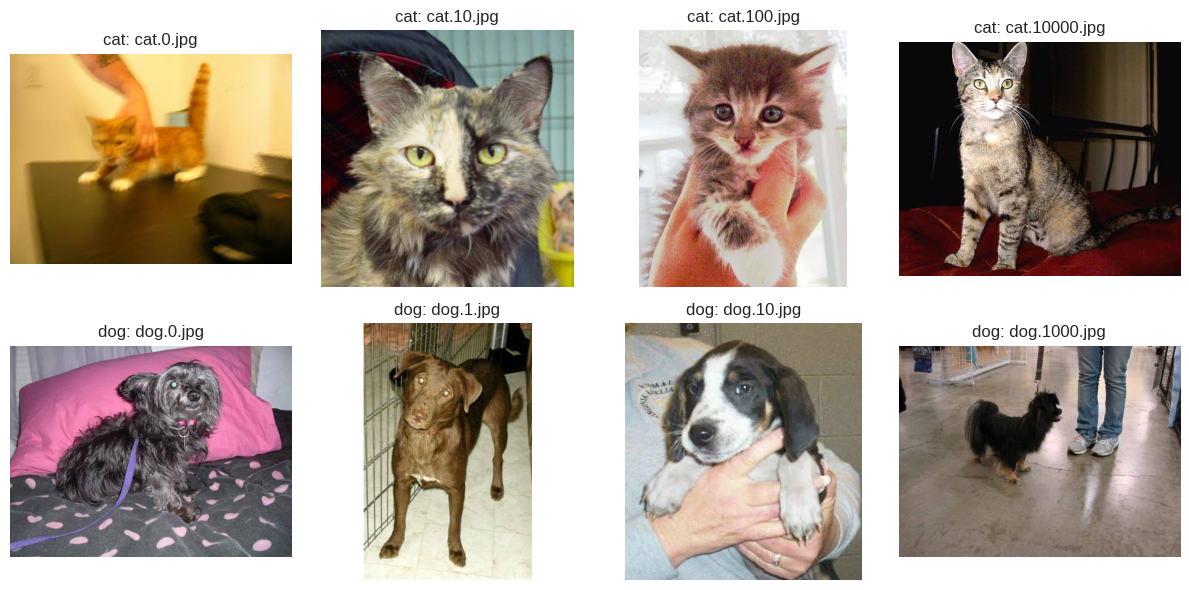

In [19]:
!apt-get -qq install -y fonts-nanum > /dev/null
!fc-cache -f

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image

# 나눔고딕 폰트 설정 (Colab 한글 깨짐 방지)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

try: plt.style.use('seaborn-v0_8-whitegrid')
except OSError: pass

def show_examples(split_name='train', n=4):
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for row, cn in enumerate(['cat', 'dog']):
        paths = sorted((SPLIT_DIR / split_name / cn).glob('*.jpg'))[:n]
        for ax, p in zip(axes[row], paths):
            ax.imshow(Image.open(p).convert('RGB'))
            ax.set_title(f'{cn}: {p.name}'); ax.axis('off')
    plt.tight_layout(); plt.show()

show_examples('train', n=4)

---
## 3. Transform과 DataLoader

- 기본 CNN 실험: `Resize + Normalize`
- 증강 CNN 실험: `RandomResizedCrop + RandomHorizontalFlip + ColorJitter + Normalize`
- 검증 / 테스트: 항상 `Resize + Normalize`만 사용

> **증강 강도에 대해**: 효과를 명확히 관찰할 수 있도록 비교적 약한 증강을 선택했습니다. 실전에서는 `RandomRotation`, `GaussianBlur`, `RandomErasing` 등도 자주 사용합니다.

In [5]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds_base = datasets.ImageFolder(SPLIT_DIR / 'train', transform=train_transform_base)
train_ds_aug  = datasets.ImageFolder(SPLIT_DIR / 'train', transform=train_transform_aug)
val_ds  = datasets.ImageFolder(SPLIT_DIR / 'val',  transform=eval_transform)
test_ds = datasets.ImageFolder(SPLIT_DIR / 'test', transform=eval_transform)

class_names = train_ds_base.classes
print('classes:', class_names)
# cat=0, dog=1 → sigmoid >= 0.5이면 dog으로 예측
print('class_to_idx:', train_ds_base.class_to_idx)

loader_args = dict(num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
train_loader_base = DataLoader(train_ds_base, batch_size=BATCH_SIZE, shuffle=True,  **loader_args)
train_loader_aug  = DataLoader(train_ds_aug,  batch_size=BATCH_SIZE, shuffle=True,  **loader_args)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, **loader_args)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_args)

classes: ['cat', 'dog']
class_to_idx: {'cat': 0, 'dog': 1}


/tmp/ipykernel_7651/3527515354.py:13: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/3527515354.py:13: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/3527515354.py:13: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/3527515354.py:13: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/3527515354.py:13: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/3527515354.py:13: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/3527515354.py:13: Us

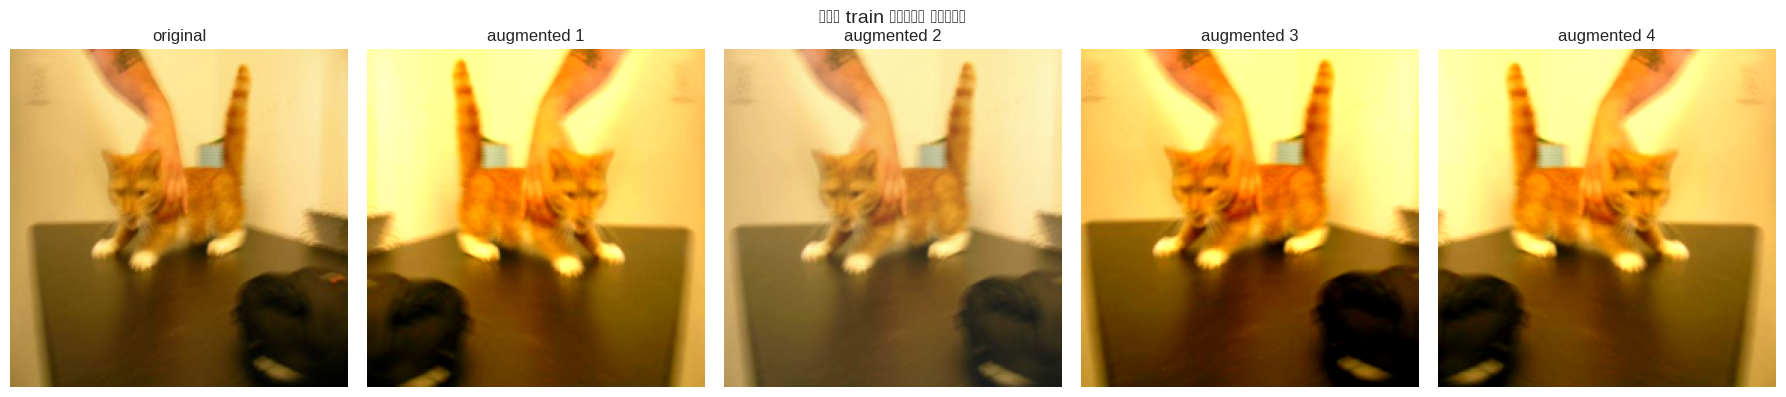

In [6]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std).view(3,1,1)
    return torch.clamp(tensor.cpu() * s + m, 0, 1)

sample_img = Image.open(sorted((SPLIT_DIR/'train'/'cat').glob('*.jpg'))[0]).convert('RGB')
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(sample_img.resize((IMG_SIZE, IMG_SIZE))); axes[0].set_title('original'); axes[0].axis('off')
for i in range(4):
    axes[i+1].imshow(denormalize(train_transform_aug(sample_img)).permute(1,2,0))
    axes[i+1].set_title(f'augmented {i+1}'); axes[i+1].axis('off')
plt.suptitle('증강은 train 데이터에만 적용합니다', fontsize=14)
plt.tight_layout(); plt.show()

---
## 4. 모델과 손실 함수

#### 왜 BCEWithLogitsLoss를 쓰는가?

| 방식 | 출력 뉴런 수 | 손실 함수 | 예측 방법 |
|------|------------|----------|----------|
| 다중 클래스 스타일 | 2개 | `CrossEntropyLoss` | `argmax` |
| **이진 분류 스타일** | **1개** | **`BCEWithLogitsLoss`** | **`sigmoid >= 0.5`** |

- logit > 0 → sigmoid > 0.5 → **dog(1)**
- logit < 0 → sigmoid < 0.5 → **cat(0)**

> `BCEWithLogitsLoss`는 내부적으로 sigmoid를 포함하므로 raw logit을 바로 넣습니다.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),   # 224→112
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),  # 112→56
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2), # 56→28
            nn.AdaptiveAvgPool2d((1, 1))                                       # 28→1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)  # 이진 분류 → 출력 1개
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

---
## 5. 훈련 도구 정의

| 함수 | 역할 |
|------|------|
| `run_epoch` | 1 에폭 학습 또는 평가 |
| `train_model` | 여러 에폭 + best model 저장 |
| `evaluate_model` | test 평가 + 예측 수집 |
| `plot_history` / `plot_confusion` | 시각화 |

In [8]:
def accuracy_from_logits(logits, labels):
    preds = (torch.sigmoid(logits) >= 0.5).long().view(-1)
    return (preds == labels.long()).sum().item()


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    running_loss = running_corrects = total = 0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels_bce = labels.float().unsqueeze(1).to(device)
        if is_train: optimizer.zero_grad()
        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, labels_bce)
            if is_train: loss.backward(); optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += accuracy_from_logits(outputs, labels_bce.view(-1))
        total += inputs.size(0)
        if not is_train:
            preds = (torch.sigmoid(outputs) >= 0.5).long().view(-1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    result = (running_loss / total, running_corrects / total)
    return (result, np.array(all_labels), np.array(all_preds)) if not is_train else result


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    best_state = deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(epochs):
        t0 = time.time()
        tl, ta = run_epoch(model, train_loader, criterion, optimizer)
        (vl, va), _, _ = run_epoch(model, val_loader, criterion)
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
        if va > best_val_acc:
            best_val_acc = va; best_state = deepcopy(model.state_dict())
        print(f'Epoch {epoch+1}/{epochs} | train_loss={tl:.4f} train_acc={ta:.4f} '
              f'val_loss={vl:.4f} val_acc={va:.4f} time={time.time()-t0:.1f}s')
    model.load_state_dict(best_state)
    return model, history


@torch.no_grad()
def evaluate_model(model, loader, criterion):
    model.eval()
    (loss, acc), labels, preds = run_epoch(model, loader, criterion)
    return {'loss': loss, 'accuracy': acc}, labels, preds


def plot_history(history, title):
    ep = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, label in [(axes[0], 'loss', 'Loss'), (axes[1], 'acc', 'Accuracy')]:
        ax.plot(ep, history[f'train_{metric}'], 'o-', label='train')
        ax.plot(ep, history[f'val_{metric}'],   'o-', label='val')
        ax.set_title(f'{title} - {label}'); ax.set_xlabel('epoch'); ax.legend()
    plt.tight_layout(); plt.show()


def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set(xticks=range(len(class_names)), yticks=range(len(class_names)),
           xticklabels=class_names, yticklabels=class_names,
           xlabel='predicted', ylabel='true', title=title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i,j], ha='center', va='center', color='black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()


results = {}

---
## 6. 기본 CNN 학습

데이터 증강 없이 작은 CNN을 처음부터 학습합니다.

#### 과적합 관찰 가이드
- **Loss**: train_loss ↓ 인데 val_loss ↑ → 과적합
- **Accuracy**: train_acc - val_acc > 10%p → 명확한 과적합
- 초반에는 둘 다 좋아지다가 어느 시점부터 train만 좋아지는 패턴을 찾아보세요

Baseline CNN trainable params: 93,377
Epoch 1/5 | train_loss=0.6838 train_acc=0.5419 val_loss=0.6615 val_acc=0.6200 time=12.4s
Epoch 2/5 | train_loss=0.6570 train_acc=0.5862 val_loss=0.6503 val_acc=0.6067 time=9.2s
Epoch 3/5 | train_loss=0.6453 train_acc=0.6148 val_loss=0.6422 val_acc=0.6044 time=8.8s
Epoch 4/5 | train_loss=0.6459 train_acc=0.6124 val_loss=0.6423 val_acc=0.6378 time=9.7s
Epoch 5/5 | train_loss=0.6378 train_acc=0.6210 val_loss=0.6364 val_acc=0.6356 time=9.7s


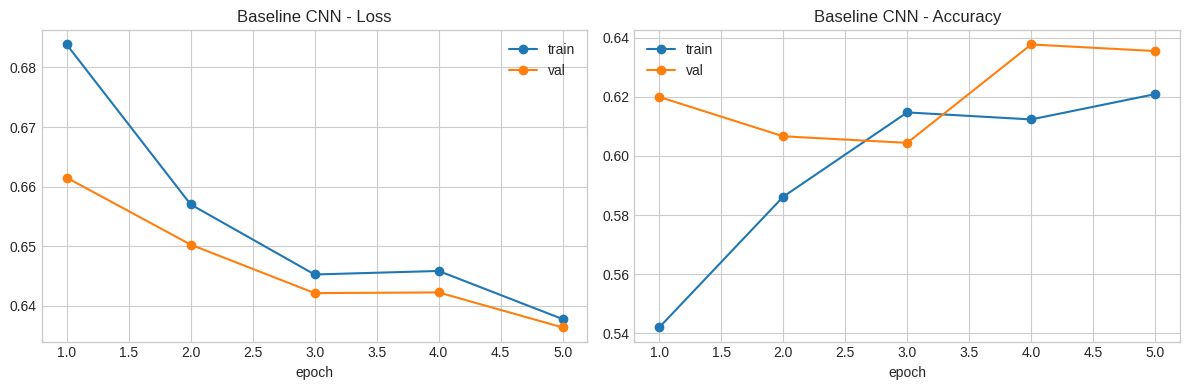

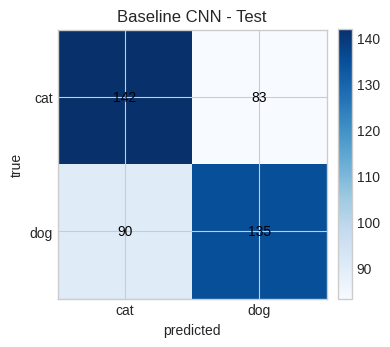

,precision,recall,f1-score,support
cat,0.612069,0.631111,0.621444,225.000000
dog,0.619266,0.600000,0.609481,225.000000
accuracy,0.615556,0.615556,0.615556,0.615556
macro avg,0.615668,0.615556,0.615463,450.000000
weighted avg,0.615668,0.615556,0.615463,450.000000


{'test_loss': 0.6488177622689141, 'test_accuracy': 0.6155555555555555, 'trainable_params': 93377}


In [9]:
baseline_model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

print(f'Baseline CNN trainable params: {count_trainable_params(baseline_model):,}')
baseline_model, baseline_history = train_model(
    baseline_model, train_loader_base, val_loader, criterion, optimizer, EPOCHS_SCRATCH
)

baseline_metrics, y_true_base, y_pred_base = evaluate_model(baseline_model, test_loader, criterion)
plot_history(baseline_history, 'Baseline CNN')
plot_confusion(y_true_base, y_pred_base, class_names, 'Baseline CNN - Test')
display(pd.DataFrame(classification_report(y_true_base, y_pred_base, target_names=class_names, output_dict=True)).T)
results['Baseline CNN'] = {'test_loss': baseline_metrics['loss'], 'test_accuracy': baseline_metrics['accuracy'],
                           'trainable_params': count_trainable_params(baseline_model)}
print(results['Baseline CNN'])

> **확인 질문**: train_acc와 val_acc의 차이는 얼마인가요? 과적합의 증거가 될 수 있을까요?

---
## 7. 이미지 증강 CNN 학습

모델 구조는 그대로 두고, train transform만 바꿉니다. 성능 차이 = 순수 증강 효과.

Augmented CNN trainable params: 93,377
Epoch 1/5 | train_loss=0.6802 train_acc=0.5776 val_loss=0.6662 val_acc=0.5933 time=13.7s
Epoch 2/5 | train_loss=0.6615 train_acc=0.5981 val_loss=0.6625 val_acc=0.5600 time=13.8s
Epoch 3/5 | train_loss=0.6483 train_acc=0.6110 val_loss=0.6646 val_acc=0.6000 time=13.8s
Epoch 4/5 | train_loss=0.6420 train_acc=0.6105 val_loss=0.6338 val_acc=0.6111 time=14.1s
Epoch 5/5 | train_loss=0.6364 train_acc=0.6124 val_loss=0.6355 val_acc=0.6000 time=13.9s


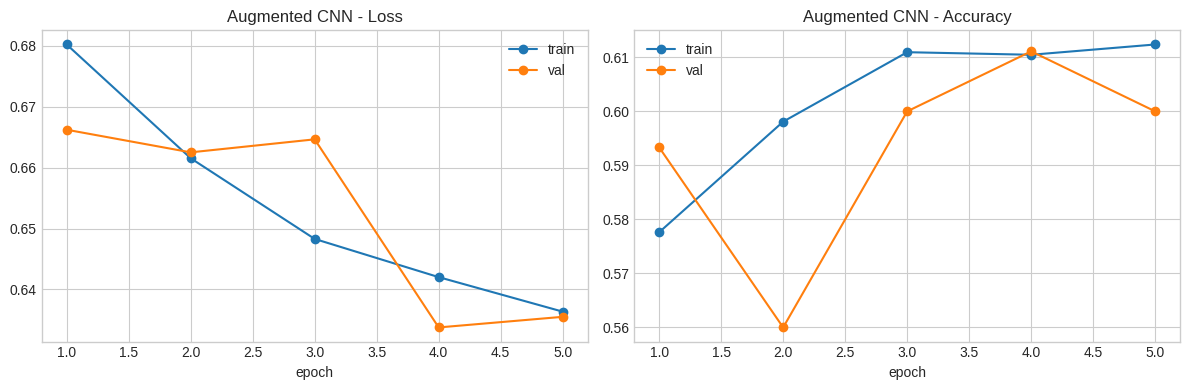

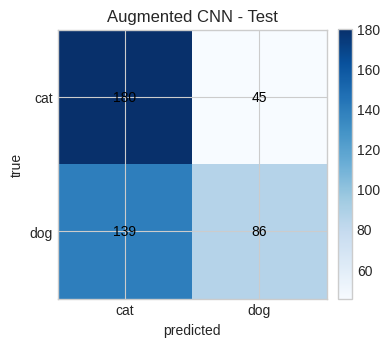

,precision,recall,f1-score,support
cat,0.564263,0.800000,0.661765,225.000000
dog,0.656489,0.382222,0.483146,225.000000
accuracy,0.591111,0.591111,0.591111,0.591111
macro avg,0.610376,0.591111,0.572455,450.000000
weighted avg,0.610376,0.591111,0.572455,450.000000


{'test_loss': 0.6397578922907511, 'test_accuracy': 0.5911111111111111, 'trainable_params': 93377}


In [10]:
aug_model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(aug_model.parameters(), lr=1e-3)

print(f'Augmented CNN trainable params: {count_trainable_params(aug_model):,}')
aug_model, aug_history = train_model(
    aug_model, train_loader_aug, val_loader, criterion, optimizer, EPOCHS_SCRATCH
)

aug_metrics, y_true_aug, y_pred_aug = evaluate_model(aug_model, test_loader, criterion)
plot_history(aug_history, 'Augmented CNN')
plot_confusion(y_true_aug, y_pred_aug, class_names, 'Augmented CNN - Test')
display(pd.DataFrame(classification_report(y_true_aug, y_pred_aug, target_names=class_names, output_dict=True)).T)
results['Augmented CNN'] = {'test_loss': aug_metrics['loss'], 'test_accuracy': aug_metrics['accuracy'],
                            'trainable_params': count_trainable_params(aug_model)}
print(results['Augmented CNN'])

> **확인 질문**: Baseline과 비교하여 과적합 정도(train_acc - val_acc)는 어떻게 변했나요?

---
## 8. 전이학습이란?

사람은 고양이를 처음 배울 때 눈, 코, 귀를 완전히 새로 배우지 않습니다. 이미 다른 동물을 보며 익힌 시각 지식이 있기 때문입니다. 전이학습도 같은 원리입니다.

```
[ImageNet 120만장으로 학습한 ResNet18]
        ↓
  이미 알고 있는 것:
  - 초기 레이어: 가장자리, 질감, 색상 패턴
  - 중간 레이어: 눈, 코, 귀, 발 같은 부분 형태
  - 깊은 레이어: 얼굴 구조, 몸체 형태 등 복합 특징
        ↓
  우리가 할 일:
  - 이 지식을 그대로 가져오고 (freeze)
  - 마지막 분류기만 "개 vs 고양이"로 교체 (새로 학습)
```

| 전략 | 방법 | 학습 파라미터 | 적합한 상황 |
|------|------|-------------|------------|
| **Feature Extraction** | 전체 freeze + 분류기만 학습 | 매우 적음 | 데이터 적거나 ImageNet과 유사 |
| **Fine-tuning** | 일부 unfreeze + 낮은 lr | 적당히 많음 | 데이터 충분하거나 도메인 약간 다름 |

---
## 9. 전이학습 실험 - Feature Extraction

ResNet18의 사전학습 가중치를 불러와서 마지막 fc만 학습합니다.
기본 transform을 사용하여, baseline과의 차이 = 순수 전이학습 효과.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 124MB/s] 


Transfer model trainable params: 513
Epoch 1/5 | train_loss=0.3557 train_acc=0.8814 val_loss=0.1888 val_acc=0.9533 time=9.8s
Epoch 2/5 | train_loss=0.1718 train_acc=0.9486 val_loss=0.1278 val_acc=0.9711 time=9.4s
Epoch 3/5 | train_loss=0.1373 train_acc=0.9562 val_loss=0.1066 val_acc=0.9756 time=9.5s
Epoch 4/5 | train_loss=0.1289 train_acc=0.9543 val_loss=0.0988 val_acc=0.9644 time=8.5s
Epoch 5/5 | train_loss=0.1187 train_acc=0.9629 val_loss=0.0880 val_acc=0.9756 time=9.5s


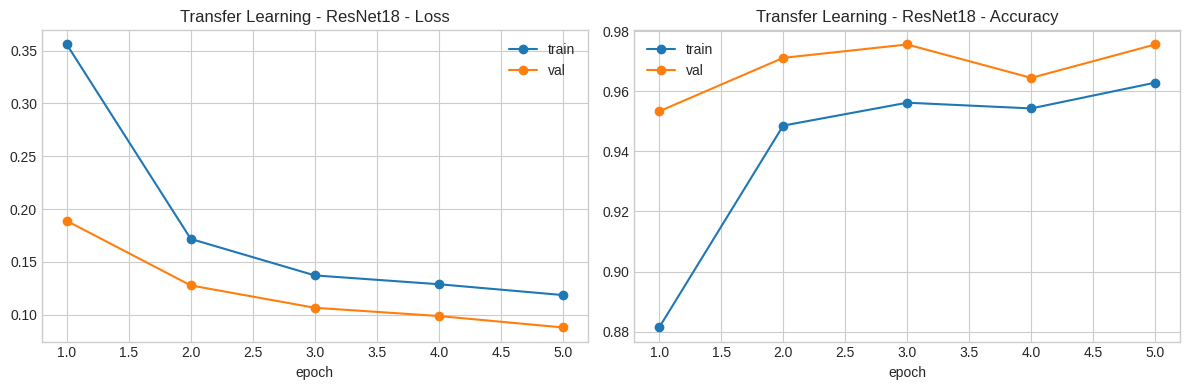

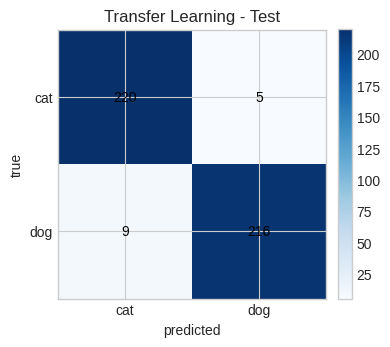

,precision,recall,f1-score,support
cat,0.960699,0.977778,0.969163,225.000000
dog,0.977376,0.960000,0.968610,225.000000
accuracy,0.968889,0.968889,0.968889,0.968889
macro avg,0.969037,0.968889,0.968886,450.000000
weighted avg,0.969037,0.968889,0.968886,450.000000


{'test_loss': 0.10145380310714244, 'test_accuracy': 0.9688888888888889, 'trainable_params': 513}


In [11]:
weights = models.ResNet18_Weights.DEFAULT
transfer_model = models.resnet18(weights=weights)
for param in transfer_model.parameters():
    param.requires_grad = False
transfer_model.fc = nn.Linear(transfer_model.fc.in_features, 1)
transfer_model = transfer_model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(transfer_model.fc.parameters(), lr=1e-3)

print(f'Transfer model trainable params: {count_trainable_params(transfer_model):,}')
transfer_model, transfer_history = train_model(
    transfer_model, train_loader_base, val_loader, criterion, optimizer, EPOCHS_TRANSFER
)

transfer_metrics, y_true_tf, y_pred_tf = evaluate_model(transfer_model, test_loader, criterion)
plot_history(transfer_history, 'Transfer Learning - ResNet18')
plot_confusion(y_true_tf, y_pred_tf, class_names, 'Transfer Learning - Test')
display(pd.DataFrame(classification_report(y_true_tf, y_pred_tf, target_names=class_names, output_dict=True)).T)
results['Transfer Learning (ResNet18)'] = {'test_loss': transfer_metrics['loss'], 'test_accuracy': transfer_metrics['accuracy'],
                                           'trainable_params': count_trainable_params(transfer_model)}
print(results['Transfer Learning (ResNet18)'])

> **확인 질문**: 학습 가능한 파라미터 수를 Baseline CNN과 비교해 보세요. 파라미터가 훨씬 적은데도 성능은 어떤가요?

---
## 10. Fine-tuning (선택 확장)

`layer4` + `fc`만 학습하고, 차등 학습률(layer4=1e-4, fc=1e-3)을 적용합니다.

> **주의**: 이 실험은 파트 9와 비교 시 **(1) layer4 unfreeze + (2) 증강** 두 변수가 동시에 바뀝니다. 순수 unfreeze 효과만 보려면 `train_loader_base`로도 실험해 보세요.

Fine-tuning trainable params: 8,394,241
Epoch 1/5 | train_loss=0.1332 train_acc=0.9500 val_loss=0.0510 val_acc=0.9822 time=14.2s
Epoch 2/5 | train_loss=0.0416 train_acc=0.9862 val_loss=0.0406 val_acc=0.9867 time=13.7s
Epoch 3/5 | train_loss=0.0248 train_acc=0.9929 val_loss=0.0626 val_acc=0.9756 time=14.1s
Epoch 4/5 | train_loss=0.0173 train_acc=0.9924 val_loss=0.0751 val_acc=0.9778 time=14.4s
Epoch 5/5 | train_loss=0.0133 train_acc=0.9967 val_loss=0.1223 val_acc=0.9733 time=13.9s


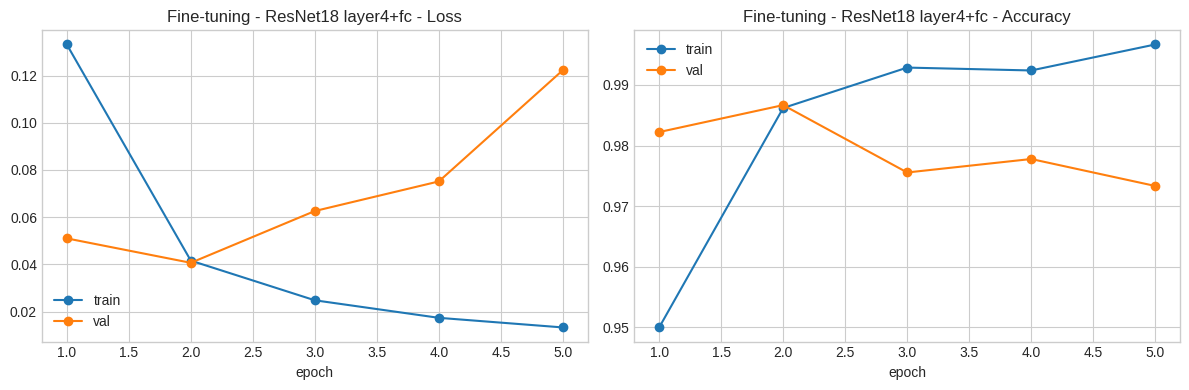

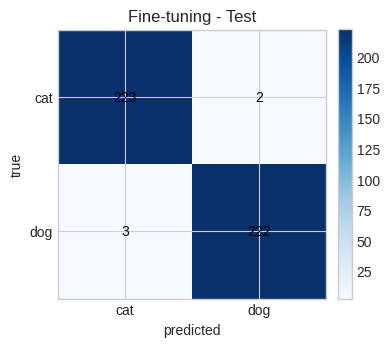

,precision,recall,f1-score,support
cat,0.986726,0.991111,0.988914,225.000000
dog,0.991071,0.986667,0.988864,225.000000
accuracy,0.988889,0.988889,0.988889,0.988889
macro avg,0.988899,0.988889,0.988889,450.000000
weighted avg,0.988899,0.988889,0.988889,450.000000


{'test_loss': 0.03456330143639611, 'test_accuracy': 0.9888888888888889, 'trainable_params': 8394241}


In [12]:
finetune_model = models.resnet18(weights=weights)
for param in finetune_model.parameters():
    param.requires_grad = False
for param in finetune_model.layer4.parameters():
    param.requires_grad = True
finetune_model.fc = nn.Linear(finetune_model.fc.in_features, 1)
finetune_model = finetune_model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam([
    {'params': finetune_model.layer4.parameters(), 'lr': 1e-4},
    {'params': finetune_model.fc.parameters(),     'lr': 1e-3}
], weight_decay=1e-4)

print(f'Fine-tuning trainable params: {count_trainable_params(finetune_model):,}')
finetune_model, finetune_history = train_model(
    finetune_model, train_loader_aug, val_loader, criterion, optimizer, EPOCHS_TRANSFER
)

ft_metrics, y_true_ft, y_pred_ft = evaluate_model(finetune_model, test_loader, criterion)
plot_history(finetune_history, 'Fine-tuning - ResNet18 layer4+fc')
plot_confusion(y_true_ft, y_pred_ft, class_names, 'Fine-tuning - Test')
display(pd.DataFrame(classification_report(y_true_ft, y_pred_ft, target_names=class_names, output_dict=True)).T)
results['Fine-tuning (ResNet18 layer4+fc)'] = {'test_loss': ft_metrics['loss'], 'test_accuracy': ft_metrics['accuracy'],
                                                'trainable_params': count_trainable_params(finetune_model)}
print(results['Fine-tuning (ResNet18 layer4+fc)'])

---
## 11. 성능 비교와 오분류 분석

,test_loss,test_accuracy,trainable_params,test_accuracy_pct
Fine-tuning (ResNet18 layer4+fc),0.034563,0.988889,8394241,98.89
Transfer Learning (ResNet18),0.101454,0.968889,513,96.89
Baseline CNN,0.648818,0.615556,93377,61.56
Augmented CNN,0.639758,0.591111,93377,59.11


/tmp/ipykernel_7651/4172839823.py:11: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/4172839823.py:11: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/4172839823.py:11: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/4172839823.py:11: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/4172839823.py:11: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw

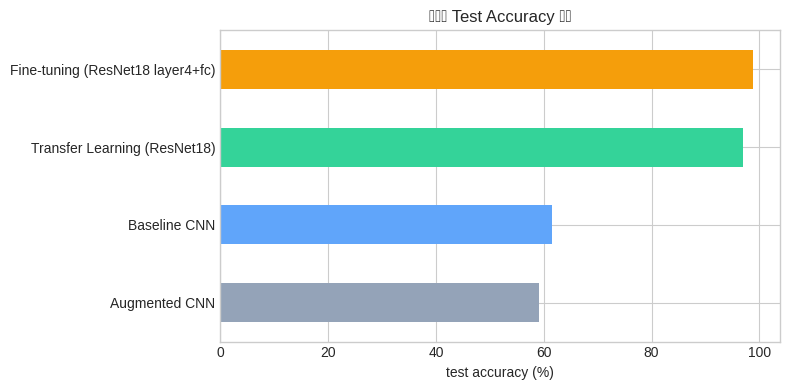

Best model: Fine-tuning (ResNet18 layer4+fc)
증강 효과: -2.44%p
전이학습 효과: +35.33%p
Fine-tuning 효과: +37.33%p


In [13]:
comparison_df = pd.DataFrame(results).T
comparison_df['test_accuracy_pct'] = (comparison_df['test_accuracy'] * 100).round(2)
comparison_df['trainable_params'] = comparison_df['trainable_params'].astype(int)
display(comparison_df.sort_values('test_accuracy', ascending=False))

plot_df = comparison_df.sort_values('test_accuracy_pct')
colors = ['#94A3B8', '#60A5FA', '#34D399', '#F59E0B'][:len(plot_df)]
fig, ax = plt.subplots(figsize=(8, 4))
plot_df['test_accuracy_pct'].plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('test accuracy (%)'); ax.set_title('모델별 Test Accuracy 비교')
plt.tight_layout(); plt.show()

best_model_name = comparison_df['test_accuracy'].idxmax()
print(f'Best model: {best_model_name}')
for name, key in [('증강', 'Augmented CNN'), ('전이학습', 'Transfer Learning (ResNet18)'),
                   ('Fine-tuning', 'Fine-tuning (ResNet18 layer4+fc)')]:
    if 'Baseline CNN' in results and key in results:
        delta = 100 * (results[key]['test_accuracy'] - results['Baseline CNN']['test_accuracy'])
        print(f'{name} 효과: {delta:+.2f}%p')

#### 오분류 이미지 시각화

가장 성능이 높은 모델이 틀린 이미지를 확인합니다. 사람이 봐도 헷갈리는 건지, 모델만 헷갈리는 건지 토론해 보세요.

/tmp/ipykernel_7651/2383486150.py:26: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) Liberation Sans.
  plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/2383486150.py:26: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) Liberation Sans.
  plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/2383486150.py:26: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) Liberation Sans.
  plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/2383486150.py:26: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) Liberation Sans.
  plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()
/tmp/ipykernel_7651/2383486150.py:26: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) Liberation Sans.
  plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist

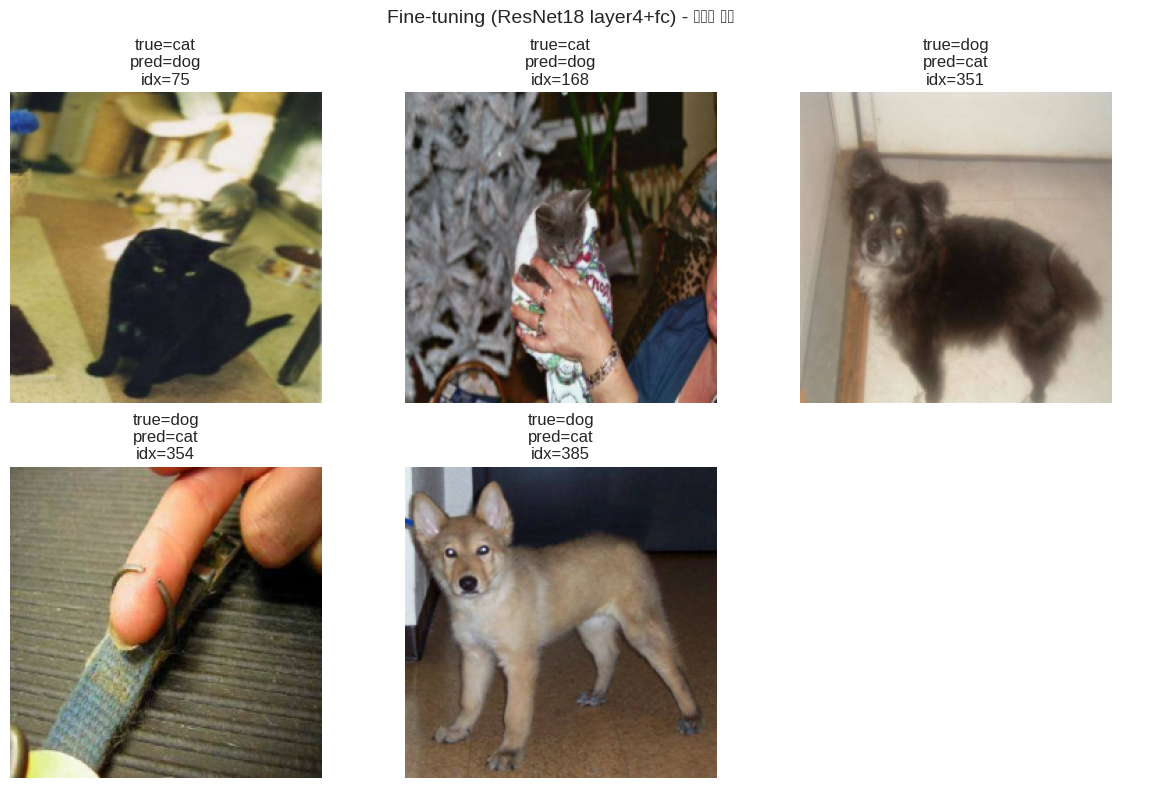

In [14]:
def collect_misclassified(model, dataset, class_names, max_items=9):
    model.eval()
    samples = []
    for idx in range(len(dataset)):
        img, label = dataset[idx]
        with torch.no_grad():
            pred = int(torch.sigmoid(model(img.unsqueeze(0).to(device))).item() >= 0.5)
        if pred != int(label):
            samples.append({'image': img, 'true': class_names[int(label)],
                            'pred': class_names[pred], 'idx': idx})
        if len(samples) >= max_items: break
    return samples


def show_misclassified(model, dataset, class_names, title, max_items=9):
    samples = collect_misclassified(model, dataset, class_names, max_items)
    if not samples: print('오분류 샘플 없음'); return
    cols = 3; rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).reshape(-1)
    for ax, s in zip(axes, samples):
        ax.imshow(denormalize(s['image']).permute(1,2,0))
        ax.set_title(f"true={s['true']}\npred={s['pred']}\nidx={s['idx']}")
        ax.axis('off')
    for ax in axes[len(samples):]: ax.axis('off')
    plt.suptitle(title, fontsize=14); plt.tight_layout(); plt.show()


registry = {'Baseline CNN': baseline_model, 'Augmented CNN': aug_model,
            'Transfer Learning (ResNet18)': transfer_model}
if 'finetune_model' in dir(): registry['Fine-tuning (ResNet18 layer4+fc)'] = finetune_model

show_misclassified(registry[best_model_name], test_ds, class_names,
                   f'{best_model_name} - 오분류 샘플')

---
## 12. 모델 저장과 웹 서비스 배포

가장 성능이 좋은 모델을 저장하고, Streamlit으로 웹 서비스를 만들어 **Streamlit Community Cloud에 무료 배포**합니다.

> **선수 학습**: Streamlit의 실행 모델, 위젯, 캐싱 등 기본 개념은 [6-2. Streamlit 기초](/deeplearning/streamlit-basics)를, 배포 방법은 [6-3. 웹서비스 배포: MNIST](/deeplearning/streamlit-mnist-deploy)를 참고하세요.

### 12-1. 모델 저장


In [15]:
import torch

# 가장 성능이 좋은 모델 선택
best_name = comparison_df['test_accuracy'].idxmax()
best_model_obj = registry[best_name]
print(f'저장할 모델: {best_name}')

# state_dict 저장
torch.save(best_model_obj.state_dict(), 'best_model.pt')
print(f'모델 저장 완료: best_model.pt ({os.path.getsize("best_model.pt") / 1e6:.1f} MB)')

저장할 모델: Fine-tuning (ResNet18 layer4+fc)
모델 저장 완료: best_model.pt (44.8 MB)


In [16]:
# Google Drive에 백업
from google.colab import drive
drive.mount('/content/drive')

import shutil
save_dir = '/content/drive/MyDrive/dogs_vs_cats_deploy'
os.makedirs(save_dir, exist_ok=True)
shutil.copy('best_model.pt', save_dir)
print(f'Google Drive 백업 완료: {save_dir}/best_model.pt')

Mounted at /content/drive
Google Drive 백업 완료: /content/drive/MyDrive/dogs_vs_cats_deploy/best_model.pt


### 12-2. 저장된 모델로 단일 이미지 예측 테스트

배포 전에, 저장된 모델을 새로 로드하여 정상 작동하는지 확인합니다.


예측: cat (100.0%)


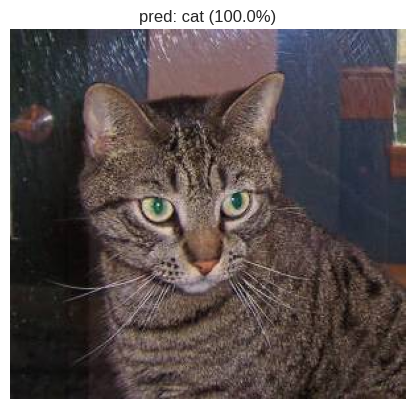

In [18]:
# 모델 구조를 다시 정의하고 가중치 로드
test_model = models.resnet18(weights=None)
test_model.fc = nn.Linear(test_model.fc.in_features, 1)
test_model.load_state_dict(torch.load('best_model.pt', map_location='cpu'))
test_model.eval()

# 테스트 이미지 1장으로 예측
sample_path = sorted((SPLIT_DIR / 'test' / 'cat').glob('*.jpg'))[0]
sample_img = Image.open(sample_path).convert('RGB')
input_tensor = eval_transform(sample_img).unsqueeze(0)

with torch.no_grad():
    logit = test_model(input_tensor)
    prob = torch.sigmoid(logit).item()
    if prob >= 0.5:
        pred_label = 'dog'
        confidence = prob
    else:
        pred_label = 'cat'
        confidence = 1 - prob

print(f'예측: {pred_label} ({confidence:.1%})')
plt.imshow(sample_img)
plt.title(f'pred: {pred_label} ({confidence:.1%})')
plt.axis('off')
plt.show()

### 12-3. Streamlit 앱 코드

아래 코드를 `app.py`로 저장합니다. 이미지를 업로드하면 모델이 개/고양이를 분류하고 확률을 표시합니다.

```python
# app.py — Dogs vs Cats 분류 웹 서비스
import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import gdown
import os

# ── 모델 로드 (앱 시작 시 1회만 실행) ──────────────────────
# https://drive.google.com/file/d/1yjAjCsvqvihbzLWFrtkoRZTsXUhEMjOI/view?usp=drive_link
MODEL_URL = "https://drive.google.com/uc?id=1yjAjCsvqvihbzLWFrtkoRZTsXUhEMjOI"
MODEL_PATH = "best_model.pt"

@st.cache_resource
def load_model():
    if not os.path.exists(MODEL_PATH):
        gdown.download(MODEL_URL, MODEL_PATH, quiet=False)
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)
    model.load_state_dict(
        torch.load(MODEL_PATH, map_location='cpu', weights_only=True)
    )
    model.eval()
    return model

model = load_model()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

st.set_page_config(page_title='Dogs vs Cats 분류기', page_icon='🐾')
st.title('🐾 Dogs vs Cats 분류기')
st.caption('이미지를 업로드하면 개인지 고양이인지 분류합니다.')

uploaded = st.file_uploader('이미지를 선택하세요', type=['jpg', 'jpeg', 'png'])

if uploaded is not None:
    image = Image.open(uploaded).convert('RGB')
    st.image(image, caption='업로드된 이미지', use_container_width=True)
    input_tensor = transform(image).unsqueeze(0)
    with torch.no_grad():
        logit = model(input_tensor)
        prob = torch.sigmoid(logit).item()
    is_dog = prob >= 0.5
    label = '🐶 Dog' if is_dog else '🐱 Cat'
    confidence = prob if is_dog else 1 - prob
    st.markdown(f'### 예측 결과: {label}')
    st.metric('확신도', f'{confidence:.1%}')
    col1, col2 = st.columns(2)
    with col1:
        st.write('🐱 Cat'); st.progress(1 - prob)
    with col2:
        st.write('🐶 Dog'); st.progress(prob)
else:
    st.info('업로드 버튼을 눌러 이미지를 선택하세요.')
```

### 12-4. Streamlit Community Cloud 배포

#### Step 1: GitHub 저장소 준비

```
dogs-vs-cats-app/
├── app.py              ← Streamlit 코드
└── requirements.txt    ← 아래 내용
```

> **모델 파일(`best_model.pt`)은 GitHub에 올리지 않습니다.** Google Drive에 업로드한 뒤, 앱이 시작할 때 자동으로 다운로드합니다.

`requirements.txt`:
```
streamlit
torch
torchvision
Pillow
gdown
```

#### Step 2: Streamlit Cloud 연결

1. [share.streamlit.io](https://share.streamlit.io/) 접속
2. GitHub 계정 연결
3. **New app** → 저장소, 브랜치, `app.py` 선택 → **Deploy**

약 2~3분 후 `https://your-app-name.streamlit.app` 영구 URL이 생성됩니다.

**핵심**: 학습된 모델을 `torch.save()`로 저장하고, Google Drive에 업로드한 뒤 Streamlit 앱에서 gdown으로 다운로드하면 GitHub 파일 크기 제한 없이 무료로 배포할 수 있다.

> **확인**: 배포된 URL에서 개/고양이 사진을 각각 업로드해 보세요. 오분류 분석에서 봤던 "헷갈리는 이미지"를 업로드하면 어떤 결과가 나오나요?

---

---
## 13. 통합 정리

#### 토론 질문
1. 기본 CNN은 어떤 오분류를 자주 만들었나요?
2. 이미지 증강은 val / test 성능을 얼마나 바꾸었나요?
3. 전이학습 모델은 왜 적은 파라미터로도 높은 성능을 낼 수 있었나요?
4. fine-tuning은 feature extraction보다 얼마나 나아졌나요?
5. 오분류 이미지는 사람이 봐도 헷갈리나요?
6. 의료 영상처럼 도메인이 크게 다르면 같은 전이학습 전략이 통할까요?

#### 확장 과제
- `USE_SMALL_SUBSET = False`로 전체 데이터 실험
- 증강 강도 바꿔 보기
- ResNet18 → MobileNetV3 / EfficientNet
- 오분류 샘플에 예측 확률 표시
- SimpleCNN에 `BatchNorm2d` 추가
- Fine-tuning을 `train_loader_base`로 실험
- `CosineAnnealingLR` 스케줄러 추가

#### 참고
- [PyTorch Transfer Learning Tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)
- [Torchvision ImageFolder](https://pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html)
- [Torchvision Transforms](https://pytorch.org/vision/stable/transforms.html)
- [Kaggle Dogs vs Cats](https://www.kaggle.com/c/dogs-vs-cats)
- [Streamlit Community Cloud](https://share.streamlit.io/)
- [Streamlit 공식 문서](https://docs.streamlit.io/)
